# MMA3001: Detecting unsealed pork packaging

This starter notebook prepares your Roboflow Version 4 YOLOv8 ZIP and fine-tunes
**YOLOv8n**. An optional cell trains **YOLOv8s** using the same settings.

**Before running:** create `MMA3001_Pork_Project` in Google Drive's **My Drive**
and upload `Pork Rasher Error-Packaging-.v4i.yolov8.zip` into that folder.
Select **Runtime > Change runtime type > Python 3 > T4 GPU** (or an available GPU).
Run code cells in order using **Shift+Enter** or the play button.

The first run uses **3 epochs**, only to confirm that the workflow works. This is
not a final accuracy experiment. An epoch is one pass through the training data.
After this succeeds, use a fresh experiment with 30 epochs for both models as an
initial comparison; inspect validation learning curves before choosing a final budget.

The original ZIP is read without modification. The prepared dataset lives in the
temporary Colab runtime; model weights, metrics, settings and logs are saved to Drive.
No Roboflow API key is needed.

**Scope:** the detector identifies regions labelled `unsealed`. An image with no
unsealed label is a negative for this target, not proof that all its packaging is sound.
This project does not establish meat freshness or food safety.


## Cell 1 — Install the training library

This uses a fixed Ultralytics version for a repeatable starting point. If Colab asks
for a runtime restart after installation, restart it, then continue with Cell 2.


In [1]:
%pip install -q ultralytics==8.4.120


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.0/96.0 kB 4.1 MB/s eta 0:00:00


## Cell 2 — Check the GPU

Expected: `GPU available: True`, followed by the GPU's name. If it says False,
select a GPU under Runtime > Change runtime type and reconnect. Free GPU availability varies.


In [ ]:
import torch
import ultralytics

print("Ultralytics:", ultralytics.__version__)
print("PyTorch:", torch.__version__)
print("GPU available:", torch.cuda.is_available())
assert torch.cuda.is_available(), "Choose an available GPU runtime before training."
print("GPU:", torch.cuda.get_device_name(0))


Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics: 8.4.120
PyTorch: 2.11.0+cu130
GPU available: True
GPU: Tesla T4


## Cell 3 — Connect Google Drive

Follow the account-selection and authorization prompts to connect your own Drive.
This lets the notebook read your ZIP and save results. You must authorize it yourself.


In [ ]:
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


New Code To Run

In [ ]:
from pathlib import Path
import json

PROJECT_DIR = Path("/content/drive/MyDrive/MMA3001_Pork_Project")
variants = ("yolov8n", "yolov8s")
candidates = []

for folder in (PROJECT_DIR / "results").glob("*"):
    records = [
        folder / "train" / variant / "completed.json"
        for variant in variants
    ]
    weights = [
        folder / "train" / variant / "weights/best.pt"
        for variant in variants
    ]

    if not all(p.is_file() for p in records + weights):
        continue

    if all(
        json.loads(p.read_text()).get("epochs_requested") == 30
        for p in records
    ):
        candidates.append(folder)

if not candidates:
    raise FileNotFoundError(
        "No completed 30-epoch comparison found. Check your Drive account."
    )

RUN_DIR = max(candidates, key=lambda folder: folder.name)
EXPERIMENT_NAME = RUN_DIR.name

saved = json.loads((RUN_DIR / "experiment.json").read_text())
settings = saved["settings"]

EPOCHS = 30
IMAGE_SIZE = settings["imgsz"]
BATCH_SIZE = settings["batch"]
SEED = settings["seed"]
TRAIN_SMALL_MODEL = True

ZIP_PATH = PROJECT_DIR / "Pork Rasher Error-Packaging-.v4i.yolov8.zip"
DATASET_DIR = Path("/content/mma3001_unsealed_dataset")

assert ZIP_PATH.is_file(), "Dataset ZIP missing from the project folder."
print("Restored experiment:", RUN_DIR)
print("Image size:", IMAGE_SIZE, "Batch size:", BATCH_SIZE)

Restored experiment: /content/drive/MyDrive/MMA3001_Pork_Project/results/20261005_053211
Image size: 640 Batch size: 8


## Cell 4 — Project settings

For the first run, leave `EPOCHS = 3` and `TRAIN_SMALL_MODEL = False`.
The ZIP must be inside `My Drive/MMA3001_Pork_Project`, with the exact filename below.
`EXPERIMENT_NAME` names a new results folder. Re-running this cell creates a new experiment.
To recover an existing run after reconnecting, set it to that run's previous folder name.


In [ ]:
from pathlib import Path
from datetime import datetime, timezone
import json
import subprocess
import hashlib
import platform

PROJECT_DIR = Path("/content/drive/MyDrive/MMA3001_Pork_Project")
ZIP_NAME = "Pork Rasher Error-Packaging-.v4i.yolov8.zip"
ZIP_PATH = PROJECT_DIR / ZIP_NAME
DATASET_DIR = Path("/content/mma3001_unsealed_dataset")

EPOCHS = 30
IMAGE_SIZE = 640
BATCH_SIZE = 8
SEED = 42
TRAIN_SMALL_MODEL = True
EXPERIMENT_NAME = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S")
RUN_DIR = PROJECT_DIR / "results" / EXPERIMENT_NAME

assert ZIP_PATH.is_file(), f"Upload your ZIP to: {ZIP_PATH}"
RUN_DIR.mkdir(parents=True, exist_ok=True)
print("ZIP:", ZIP_PATH)
print("Results:", RUN_DIR)
print("Epochs:", EPOCHS)


ZIP: /content/drive/MyDrive/MMA3001_Pork_Project/Pork Rasher Error-Packaging-.v4i.yolov8.zip
Results: /content/drive/MyDrive/MMA3001_Pork_Project/results/20261005_053211
Epochs: 30


New Code To Run 3

In [2]:
from pathlib import Path
from google.colab import drive
import json

drive.mount("/content/drive")

PROJECT_DIR = Path(
    "/content/drive/MyDrive/MMA3001_Pork_Project"
)
ZIP_NAME = "Pork Rasher Error-Packaging-.v4i.yolov8.zip"
ZIP_PATH = PROJECT_DIR / ZIP_NAME
DATASET_DIR = Path("/content/mma3001_unsealed_dataset")

RUN_DIR = PROJECT_DIR / "results" / "20261005_053211"

settings = json.loads(
    (RUN_DIR / "experiment.json").read_text()
)["settings"]

EPOCHS = settings["epochs"]
IMAGE_SIZE = settings["imgsz"]
BATCH_SIZE = settings["batch"]
SEED = settings["seed"]
TRAIN_SMALL_MODEL = True

print("Restored experiment:", RUN_DIR)

Mounted at /content/drive
Restored experiment: /content/drive/MyDrive/MMA3001_Pork_Project/results/20261005_053211


## Cell 5 — Prepare the single-class dataset

This retains all images, keeps only `unsealed` bounding boxes and remaps their class
ID from 3 to 0. It writes a new `data.yaml` with correct runtime paths.
Other defect labels are omitted because this experiment has one target.

It checks label shape, class IDs, finite values and box bounds. Duplicate ZIP entries
are accepted only if their contents match (your ZIP contains three identical `data.yaml` entries).


In [3]:
from zipfile import ZipFile
from pathlib import PurePosixPath
from collections import Counter
import math
import yaml
import pandas as pd

def prepare_unsealed_dataset(zip_path, destination):
    """Copy images and write validated single-class YOLO labels from an archive.

    Parameters
    ----------
    zip_path : pathlib.Path
        Original Roboflow YOLOv8 ZIP, read without modification.
    destination : pathlib.Path
        Directory for generated images, labels and YAML.

    Returns
    -------
    tuple
        Generated YAML path and per-split image/box counts.

    Raises
    ------
    ValueError
        Invalid labels, conflicting duplicate entries or unexpected class definitions.
    FileNotFoundError
        A split or matching image label is missing.
    """
    destination = Path(destination).resolve()
    destination.mkdir(parents=True, exist_ok=True)
    rows = []
    with ZipFile(zip_path) as archive:
        members = {}
        for info in archive.infolist():
            if info.is_dir():
                continue
            name = info.filename
            parts = PurePosixPath(name)
            if parts.is_absolute() or ".." in parts.parts or "\\" in name:
                raise ValueError(f"Unexpected archive path: {name}")
            if name in members and archive.read(members[name]) != archive.read(info):
                raise ValueError(f"Conflicting duplicate ZIP entry: {name}")
            members[name] = info

        original = yaml.safe_load(archive.read(members["data.yaml"]))
        names = original["names"]
        if isinstance(names, dict):
            names = [names[i] if i in names else names[str(i)] for i in range(len(names))]
        target_id = names.index("unsealed")
        if original["nc"] != len(names):
            raise ValueError("Class count and class names disagree.")

        for split in ("train", "valid", "test"):
            image_dir = destination / split / "images"
            label_dir = destination / split / "labels"
            image_dir.mkdir(parents=True, exist_ok=True)
            label_dir.mkdir(parents=True, exist_ok=True)
            image_names = sorted(name for name in members
                                 if name.startswith(f"{split}/images/")
                                 and PurePosixPath(name).suffix.lower() in {".jpg", ".jpeg", ".png"})
            if not image_names:
                raise FileNotFoundError(f"No images found in {split}.")
            target_images = target_boxes = 0
            seen_stems = set()
            for name in image_names:
                image_name = PurePosixPath(name).name
                stem = PurePosixPath(name).stem
                if stem in seen_stems:
                    raise ValueError(f"Ambiguous image stem in {split}: {stem}")
                seen_stems.add(stem)
                label_name = f"{split}/labels/{stem}.txt"
                if label_name not in members:
                    raise FileNotFoundError(f"Missing label: {label_name}")
                selected = []
                label_text = archive.read(members[label_name]).decode("utf-8")
                for number, line in enumerate(label_text.splitlines(), start=1):
                    if not line.strip():
                        continue
                    values = list(map(float, line.split()))
                    if len(values) != 5 or not all(math.isfinite(v) for v in values):
                        raise ValueError(f"Invalid record: {label_name}:{number}")
                    cls, x, y, w, h = values
                    if int(cls) != cls or not 0 <= cls < len(names):
                        raise ValueError(f"Invalid class: {label_name}:{number}")
                    if not (0 <= x <= 1 and 0 <= y <= 1 and 0 < w <= 1 and 0 < h <= 1):
                        raise ValueError(f"Invalid box: {label_name}:{number}")
                    if min(x - w/2, y - h/2) < -1e-5 or max(x + w/2, y + h/2) > 1 + 1e-5:
                        raise ValueError(f"Box outside image: {label_name}:{number}")
                    if int(cls) == target_id:
                        selected.append("0 " + " ".join(line.split()[1:]))
                (image_dir / image_name).write_bytes(archive.read(members[name]))
                (label_dir / f"{stem}.txt").write_text("\n".join(selected) + ("\n" if selected else ""))
                target_images += bool(selected)
                target_boxes += len(selected)
            rows.append({"split": split, "images": len(image_names),
                         "images_with_unsealed": target_images,
                         "images_without_unsealed": len(image_names) - target_images,
                         "unsealed_boxes": target_boxes})

    config = {"path": str(destination), "train": "train/images", "val": "valid/images",
              "test": "test/images", "nc": 1, "names": {0: "unsealed"}}
    yaml_path = destination / "data.yaml"
    yaml_path.write_text(yaml.safe_dump(config, sort_keys=False))
    return yaml_path, rows

DATA_YAML, DATASET_COUNTS = prepare_unsealed_dataset(ZIP_PATH, DATASET_DIR)
counts_table = pd.DataFrame(DATASET_COUNTS)
display(counts_table)
counts_table.to_csv(RUN_DIR / "dataset_counts.csv", index=False)
print(DATA_YAML.read_text())


,split,images,images_with_unsealed,images_without_unsealed,unsealed_boxes
0,train,3349,1055,2294,1055
1,valid,120,81,39,81
2,test,80,49,31,49


path: /content/mma3001_unsealed_dataset
train: train/images
val: valid/images
test: test/images
nc: 1
names:
  0: unsealed



## Cell 6 — Check the prepared labels

Expected image counts: train **3349**, valid **120**, test **80**.
Expected unsealed boxes: train **1055**, valid **81**, test **49**.
The box class ID must now always be 0. Test labels are used here only to audit data
integrity; model-selection work below uses the validation split, not test predictions.


In [4]:
expected = {"train": (3349, 1055), "valid": (120, 81), "test": (80, 49)}
for row in DATASET_COUNTS:
    assert (row["images"], row["unsealed_boxes"]) == expected[row["split"]], row
for split in ("train", "valid", "test"):
    for label in (DATASET_DIR / split / "labels").glob("*.txt"):
        for line in label.read_text().splitlines():
            assert line.split()[0] == "0", f"Unexpected class ID in {label}"
assert yaml.safe_load(DATA_YAML.read_text())["nc"] == 1
print("Preparation checks passed.")


Preparation checks passed.


## Cell 7 — Inspect six training annotations

Green rectangles show the target annotations. Check whether each rectangle encloses
the region you understand as unsealed packaging. Labels are not automatically ground
truth for physical seal integrity; discuss their meaning and limitations in your report.


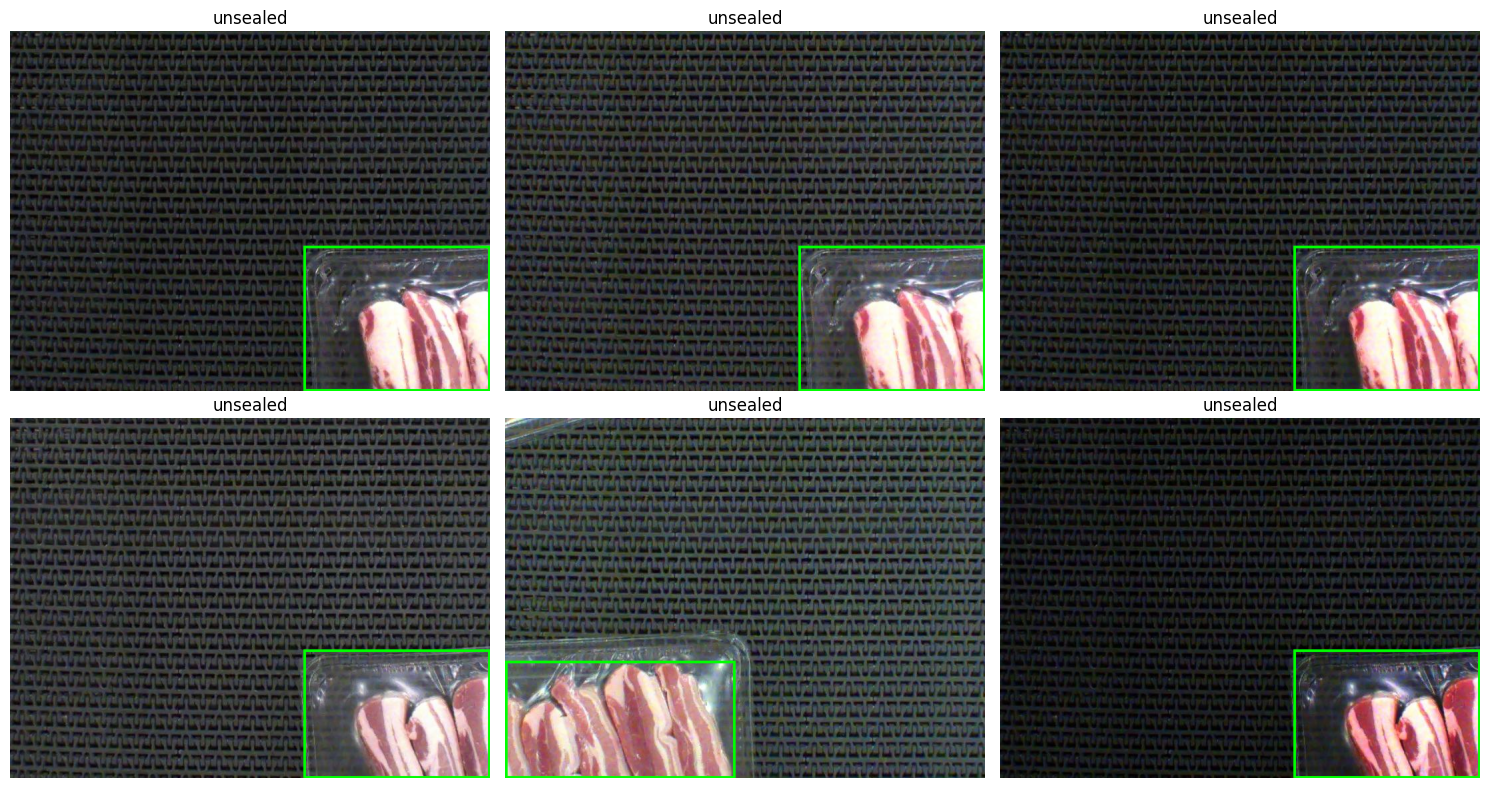

In [ ]:
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

positive_labels = [p for p in sorted((DATASET_DIR / "train/labels").glob("*.txt"))
                   if p.read_text().strip()]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, label in zip(axes.flat, positive_labels[:6]):
    candidates = list((DATASET_DIR / "train/images").glob(label.stem + ".*"))
    image = Image.open(candidates[0]).convert("RGB")
    draw = ImageDraw.Draw(image)
    for line in label.read_text().splitlines():
        _, x, y, w, h = map(float, line.split())
        draw.rectangle(((x-w/2)*image.width, (y-h/2)*image.height,
                        (x+w/2)*image.width, (y+h/2)*image.height), outline="lime", width=4)
    ax.imshow(image)
    ax.set_title("unsealed")
    ax.axis("off")
plt.tight_layout()
plt.show()


## Cell 8 — Record the experiment

This saves the runtime, package versions, dataset checksum and selected settings.
Reproducibility still depends on the GPU/runtime, so record any changes you make.

**Evaluation limitation:** these images appear to be video frames. The supplied
splits have repeated frame-name prefixes, and names alone do not establish whether
images came from the same recording or tray. Before the final assessment, inspect
near-duplicate frames and confirm whether splitting by recording/tray is possible.
The supplied split is a starting point, not proof of independent test examples.


In [ ]:
from ultralytics import YOLO
import time

COMMON_TRAIN_SETTINGS = dict(
    data=str(DATA_YAML), epochs=EPOCHS, imgsz=IMAGE_SIZE, batch=BATCH_SIZE,
    device=0, workers=2, seed=SEED, deterministic=True,
    optimizer="AdamW", lr0=0.001, patience=EPOCHS + 1,
    cache=False, save=True, plots=True,
    mosaic=0.0, mixup=0.0, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0,
    degrees=0.0, translate=0.0, scale=0.0, shear=0.0,
    perspective=0.0, flipud=0.0, fliplr=0.0,
)
# The ZIP already includes augmented training images; extra image augmentation is
# disabled here so both initial models have a simple, matching comparison protocol.
with ZIP_PATH.open("rb") as source:
    zip_sha256 = hashlib.file_digest(source, "sha256").hexdigest()
record = {"experiment": EXPERIMENT_NAME, "zip_sha256": zip_sha256,
          "python": platform.python_version(), "ultralytics": ultralytics.__version__,
          "torch": torch.__version__, "gpu": torch.cuda.get_device_name(0),
          "settings": COMMON_TRAIN_SETTINGS,
          "source": "Roboflow hello-2aqe0/pork-rasher-error-packaging, version 4",
          "license": "CC BY 4.0", "target": "unsealed"}
(RUN_DIR / "experiment.json").write_text(json.dumps(record, indent=2))
installed = subprocess.check_output(["python", "-m", "pip", "freeze"], text=True)
(RUN_DIR / "environment.txt").write_text(installed)
print("Experiment settings saved to", RUN_DIR)


Experiment settings saved to /content/drive/MyDrive/MMA3001_Pork_Project/results/20261005_053211


## Cell 9 — Train YOLOv8n

The pretrained weights download automatically. They contain general visual knowledge;
fine-tuning teaches the model your annotated target. Checkpoints and logs save to Drive.
Run this cell once per experiment. Training time depends on GPU availability and hardware.


In [ ]:
def train_variant(variant):
    """Fine-tune one model using the common protocol and save completion metadata."""
    target = RUN_DIR / "train" / variant
    completed = target / "completed.json"
    if completed.exists():
        print("Using the completed run:", target)
        return YOLO(str(target / "weights/best.pt"))
    if target.exists():
        raise RuntimeError("An unfinished run already exists. Resume from last.pt "
                           "using the recovery instructions at the end, or start a new experiment.")
    model = YOLO(f"{variant}.pt")
    start = time.perf_counter()
    model.train(**COMMON_TRAIN_SETTINGS, project=str(RUN_DIR / "train"),
                name=variant, exist_ok=False)
    seconds = time.perf_counter() - start
    completed.write_text(json.dumps({"variant": variant, "training_seconds": seconds,
                                     "epochs_requested": EPOCHS}, indent=2))
    print("Best checkpoint:", target / "weights/best.pt")
    return YOLO(str(target / "weights/best.pt"))

nano_model = train_variant("yolov8n")


New https://pypi.org/project/ultralytics/8.4.173 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.120 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/mma3001_unsealed_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.

## Cell 10 — Optional: train YOLOv8s

This is skipped on the first run. Later set `TRAIN_SMALL_MODEL = True` and run this
cell after the nano run, without changing other settings or the experiment folder.
For a longer comparison, change EPOCHS in Cell 4, create a new experiment, and re-run
the preparation and training cells for both models with the same GPU and settings.


In [ ]:
if TRAIN_SMALL_MODEL:
    small_model = train_variant("yolov8s")
else:
    print("Skipped YOLOv8s for this initial setup run.")


New https://pypi.org/project/ultralytics/8.4.173 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.120 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/mma3001_unsealed_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.

## Cell 11 — Compare on the validation split

Precision asks how many reported detections are correct; recall asks how many
annotated target objects are found. mAP combines detection performance across
confidence thresholds (mAP50-95 also varies the required box overlap).

Use these validation results to develop/select your method. `inference_ms_per_image`
is the model's reported inference component, not end-to-end production-line latency.
Timing is comparable only with the same hardware and evaluation settings.


In [ ]:
comparison_rows = []
for variant in ("yolov8n", "yolov8s"):
    model_dir = RUN_DIR / "train" / variant
    completion = model_dir / "completed.json"
    if not completion.exists():
        continue
    model = YOLO(str(model_dir / "weights/best.pt"))
    metrics = model.val(data=str(DATA_YAML), split="val", imgsz=IMAGE_SIZE,
                        batch=BATCH_SIZE, device=0, workers=2,
                        project=str(RUN_DIR / "validation"), name=variant,
                        exist_ok=True, plots=True)
    timing = json.loads(completion.read_text())
    comparison_rows.append({"model": variant, "precision": float(metrics.box.mp),
                            "recall": float(metrics.box.mr), "mAP50": float(metrics.box.map50),
                            "mAP50_95": float(metrics.box.map),
                            "inference_ms_per_image": float(metrics.speed["inference"]),
                            "training_seconds": timing["training_seconds"]})
comparison = pd.DataFrame(comparison_rows)
display(comparison)
comparison.to_csv(RUN_DIR / "validation_comparison.csv", index=False)


Ultralytics 8.4.120 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1744.4±534.7 MB/s, size: 66.6 KB)
val: Scanning /content/mma3001_unsealed_dataset/valid/labels.cache... 120 images, 39 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 120/120 36.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 6.7it/s 2.2s
                   all        120         81      0.909      0.877      0.901      0.516
Speed: 2.7ms preprocess, 5.8ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to /content/drive/MyDrive/MMA3001_Pork_Project/results/20261005_053211/validation/yolov8n
Ultralytics 8.4.120 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.

,model,precision,recall,mAP50,mAP50_95,inference_ms_per_image,training_seconds
0,yolov8n,0.908803,0.876543,0.901393,0.515657,5.773840,1602.619822
1,yolov8s,0.923709,0.790123,0.869351,0.512840,9.571009,2043.050237


## Cell 12 — View validation predictions

These are predictions from the trained nano model on six validation images.
A three-epoch run may produce few detections; that does not establish model failure.
Use a longer, justified training budget after confirming setup.


Results saved to /content/drive/MyDrive/MMA3001_Pork_Project/results/20261005_053211/predictions/yolov8n_validation


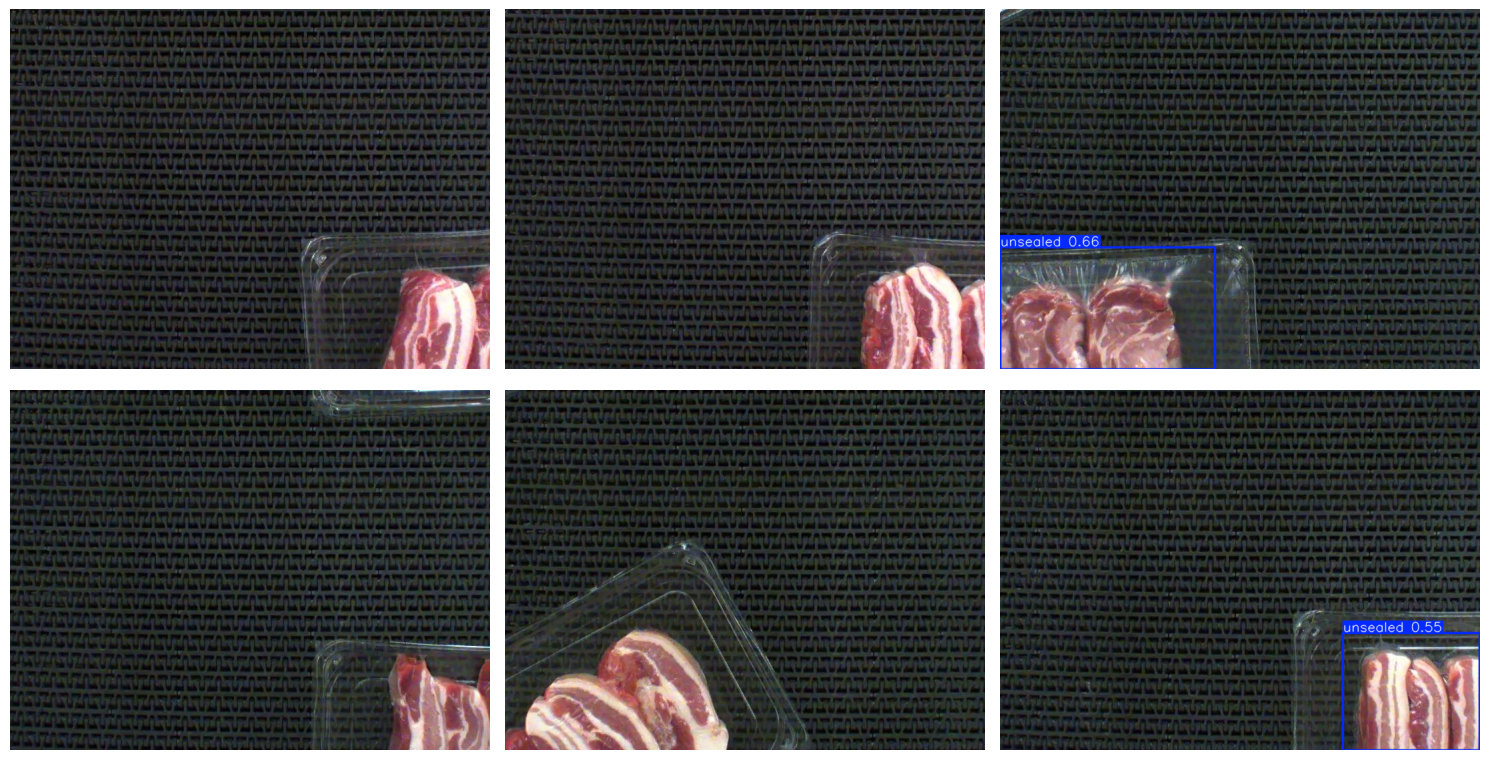

In [ ]:
validation_images = sorted((DATASET_DIR / "valid/images").glob("*"))[:6]
model = YOLO(str(RUN_DIR / "train/yolov8n/weights/best.pt"))
predictions = model.predict(source=[str(p) for p in validation_images],
                            imgsz=IMAGE_SIZE, conf=0.25, device=0,
                            save=True, project=str(RUN_DIR / "predictions"),
                            name="yolov8n_validation", exist_ok=True, verbose=False)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, result in zip(axes.flat, predictions):
    ax.imshow(result.plot()[..., ::-1])  # YOLO plots use BGR; matplotlib needs RGB.
    ax.axis("off")
plt.tight_layout()
plt.show()


New Code To Run 2

In [ ]:
import json
import pandas as pd
from ultralytics import YOLO

# Check that we are using the completed 30-epoch comparison.
print("Experiment folder:", RUN_DIR)

for variant in ("yolov8n", "yolov8s"):
    folder = RUN_DIR / "train" / variant
    record = json.loads((folder / "completed.json").read_text())

    assert record["epochs_requested"] == 30, (
        f"{variant}: this is not the 30-epoch experiment."
    )
    assert len(pd.read_csv(folder / "results.csv")) == 30, (
        f"{variant}: check the number of completed training epochs."
    )

# Use the same nano checkpoint at both resolutions.
model = YOLO(
    str(RUN_DIR / "train/yolov8n/weights/best.pt")
)

rows = []

for size in (416, 640):
    metrics = model.val(
        data=str(DATA_YAML),
        split="val",
        imgsz=size,
        batch=BATCH_SIZE,
        device=0,
        workers=2,
        project=str(RUN_DIR / "resolution_study"),
        name=f"yolov8n_{size}",
        exist_ok=True,
        plots=True,
    )

    rows.append({
        "model": "yolov8n",
        "image_size": size,
        "precision": float(metrics.box.mp),
        "recall": float(metrics.box.mr),
        "mAP50": float(metrics.box.map50),
        "mAP50_95": float(metrics.box.map),
        "inference_ms_per_image": float(metrics.speed["inference"]),
    })

study = pd.DataFrame(rows)
display(study)

output_path = RUN_DIR / "resolution_study.csv"
study.to_csv(output_path, index=False)
print("Saved:", output_path)

Experiment folder: /content/drive/MyDrive/MMA3001_Pork_Project/results/20261005_053211
Ultralytics 8.4.120 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1041.1±620.2 MB/s, size: 65.8 KB)
val: Scanning /content/mma3001_unsealed_dataset/valid/labels... 120 images, 39 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 120/120 1.5Kit/s 0.1s
val: New cache created: /content/mma3001_unsealed_dataset/valid/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 4.7it/s 3.2s
                   all        120         81      0.802       0.65      0.756      0.305
Speed: 1.7ms preprocess, 5.2ms inference, 0.0ms loss, 2.4ms postprocess per image
Results saved to /content/drive/MyDrive/MMA3001_Pork_Project/results/20261005_053211/resolution_study/yolov8n_416
Ultralytics 8.4.120 🚀 Python-3.13

,model,image_size,precision,recall,mAP50,mAP50_95,inference_ms_per_image
0,yolov8n,416,0.801965,0.649982,0.755945,0.304910,5.166587
1,yolov8n,640,0.908803,0.876543,0.901393,0.515657,5.304525


Saved: /content/drive/MyDrive/MMA3001_Pork_Project/results/20261005_053211/resolution_study.csv


## Cell 13 — Final test evaluation (disabled during setup)

Leave this disabled until you have selected the final method and frozen its settings
using validation results. Do not use repeated test checks to choose the model.
Set `FINAL_VARIANT` to your selected completed model, then set `RUN_FINAL_TEST = True`.
Test metrics apply to this labelled dataset; they do not prove seal integrity in production.


In [6]:
from pathlib import Path
from ultralytics import YOLO
import ultralytics
import torch
import json

RUN_FINAL_TEST = True
FINAL_VARIANT = "yolov8n"
FINAL_IMAGE_SIZE = 640

RUN_DIR = Path(
    "/content/drive/MyDrive/MMA3001_Pork_Project/"
    "results/20261005_053211"
)
DATA_YAML = Path("/content/mma3001_unsealed_dataset/data.yaml")

settings = json.loads(
    (RUN_DIR / "experiment.json").read_text()
)["settings"]

weights = RUN_DIR / "train" / FINAL_VARIANT / "weights/best.pt"
result_path = RUN_DIR / "final_test_metrics.json"

if not RUN_FINAL_TEST:
    print("Final test disabled.")

elif result_path.exists():
    print("Previously saved final test results:")
    print(result_path.read_text())

else:
    assert weights.is_file(), "Saved checkpoint missing."
    assert DATA_YAML.is_file(), "Restore the dataset using cells 5–6."


    design = {
        "model": FINAL_VARIANT,
        "image_size": FINAL_IMAGE_SIZE,
        "checkpoint": str(weights),
        "data_yaml": str(DATA_YAML),
        "split": "test",
        "batch_size": settings["batch"],
        "gpu": None,
        "evaluation_device": "cpu",
        "ultralytics_version": ultralytics.__version__,
        "torch_version": torch.__version__,
    }

    # Record the selected design before examining test results.
    (RUN_DIR / "final_design.json").write_text(
        json.dumps(design, indent=2)
    )

    model = YOLO(str(weights))
    metrics = model.val(
        data=str(DATA_YAML),
        split="test",
        imgsz=FINAL_IMAGE_SIZE,
        batch=settings["batch"],
        device="cpu",
        workers=2,
        project=str(RUN_DIR / "final_test"),
        name=FINAL_VARIANT,
        exist_ok=True,
        plots=True,
    )

    final_record = {
        **design,
        "precision": float(metrics.box.mp),
        "recall": float(metrics.box.mr),
        "mAP50": float(metrics.box.map50),
        "mAP50_95": float(metrics.box.map),
        "inference_ms_per_image": float(metrics.speed["inference"]),
    }

    result_path.write_text(json.dumps(final_record, indent=2))
    print(json.dumps(final_record, indent=2))
    print("Saved:", result_path)

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.120 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2056.1±670.1 MB/s, size: 66.0 KB)
val: Scanning /content/mma3001_unsealed_dataset/test/labels... 80 images, 31 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 80/80 1.2Kit/s 0.1s
val: New cache created: /content/mma3001_unsealed_dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 2.0s/it 19.6s
                   all         80         49      0.879      0.755        0.8       0.46
Speed: 7

## Saved results and recovery

Your Google Drive project folder contains:

- Original dataset ZIP.
- `results/<experiment>/experiment.json`, `environment.txt`, and `dataset_counts.csv`.
- `results/<experiment>/train/<model>/weights/best.pt` and `last.pt`.
- Per-model training `results.csv`, `args.yaml`, and plots.
- `validation_comparison.csv` and prediction examples.

The notebook is saved separately in your Drive when you choose **File > Save a copy in Drive**.
Save an `.ipynb` copy and add your code/documentation to the required GitHub repository.

If the runtime resets, reconnect the GPU, re-run Cells 1-3, set `EXPERIMENT_NAME` in
Cell 4 to the previous results folder's name, and re-run Cells 4-8 to recreate the local dataset.
An interrupted run can resume after at least one epoch has saved `last.pt`:

```python
variant = "yolov8n"  # change to yolov8s for that run
model = YOLO(str(RUN_DIR / "train" / variant / "weights/last.pt"))
start = time.perf_counter()
model.train(resume=True)
elapsed = time.perf_counter() - start
(RUN_DIR / "train" / variant / "completed.json").write_text(json.dumps({
    "variant": variant,
    "training_seconds": None,
    "resume_segment_seconds": elapsed,
    "epochs_requested": EPOCHS
}, indent=2))
```

Total training time is unknown after this recovery unless you recorded earlier
segments; do not substitute the last segment's time for the full run.
If CUDA runs out of memory, restart the runtime, reduce BATCH_SIZE from 8 to 4,
and start a new experiment using the same reduced batch size for both models.

## Report and AI-use notes

This notebook is a starter, not a finished assessment. Add your own engineering
justification, annotation audit, data-split analysis, learning-curve interpretation,
failure examples, sensitivity study and conclusions. For a simple sensitivity study,
compare two image sizes with the same model/training budget on validation data.

Disclose that ChatGPT drafted this notebook. The dataset-conversion function and
expected counts were checked locally against the supplied archive. Model training
and Colab execution still need to be run and checked by you. Record AI contributions,
errors, corrections and the decisions you made yourself.

## Sources

- Ultralytics YOLOv8 models: https://docs.ultralytics.com/models/yolov8/
- Training API/settings: https://docs.ultralytics.com/modes/train/
- Google Colab FAQ: https://research.google.com/colaboratory/faq.html
- Dataset: https://universe.roboflow.com/hello-2aqe0/pork-rasher-error-packaging/dataset/4
- Dataset licence: CC BY 4.0. Attribute the source in your report and repository.


In [ ]:
from pathlib import Path
from google.colab import drive
import json

if not Path("/content/drive/MyDrive").exists():
    drive.mount("/content/drive")

results_root = Path(
    "/content/drive/MyDrive/MMA3001_Pork_Project/results"
)

# Find completed three-epoch nano runs.
setup_runs = []
for file in results_root.glob("*/train/yolov8n/completed.json"):
    record = json.loads(file.read_text())
    if record.get("epochs_requested") == 3:
        setup_runs.append(file)

if not setup_runs:
    raise FileNotFoundError(
        "No completed three-epoch run found. "
        "Check your Drive account and whether Cell 9 finished."
    )

completion = max(setup_runs, key=lambda file: file.stat().st_mtime)
RUN_DIR = completion.parents[2]
info = json.loads(completion.read_text())

seconds = info.get("training_seconds")
if seconds is None:
    duration = "Total duration unknown: training was resumed."
else:
    duration = f"{seconds:.1f} seconds ({seconds / 60:.2f} minutes)"

note_path = RUN_DIR / "three_epoch_setup_run.txt"
note_path.write_text(
    "Three-epoch setup run\n"
    "Model: YOLOv8n\n"
    "Epochs: 3\n"
    f"Training duration: {duration}\n"
    "Purpose: check that the workflow runs successfully.\n",
    encoding="utf-8"
)

print("Selected experiment:", RUN_DIR.name)
print("Training duration:", duration)
print("Saved run label:", note_path)
print("Prediction images:", RUN_DIR / "predictions/yolov8n_validation")

Mounted at /content/drive
Selected experiment: 20261005_031241
Training duration: 193.5 seconds (3.23 minutes)
Saved run label: /content/drive/MyDrive/MMA3001_Pork_Project/results/20261005_031241/three_epoch_setup_run.txt
Prediction images: /content/drive/MyDrive/MMA3001_Pork_Project/results/20261005_031241/predictions/yolov8n_validation


New Code To Run 4

Confusion matrix


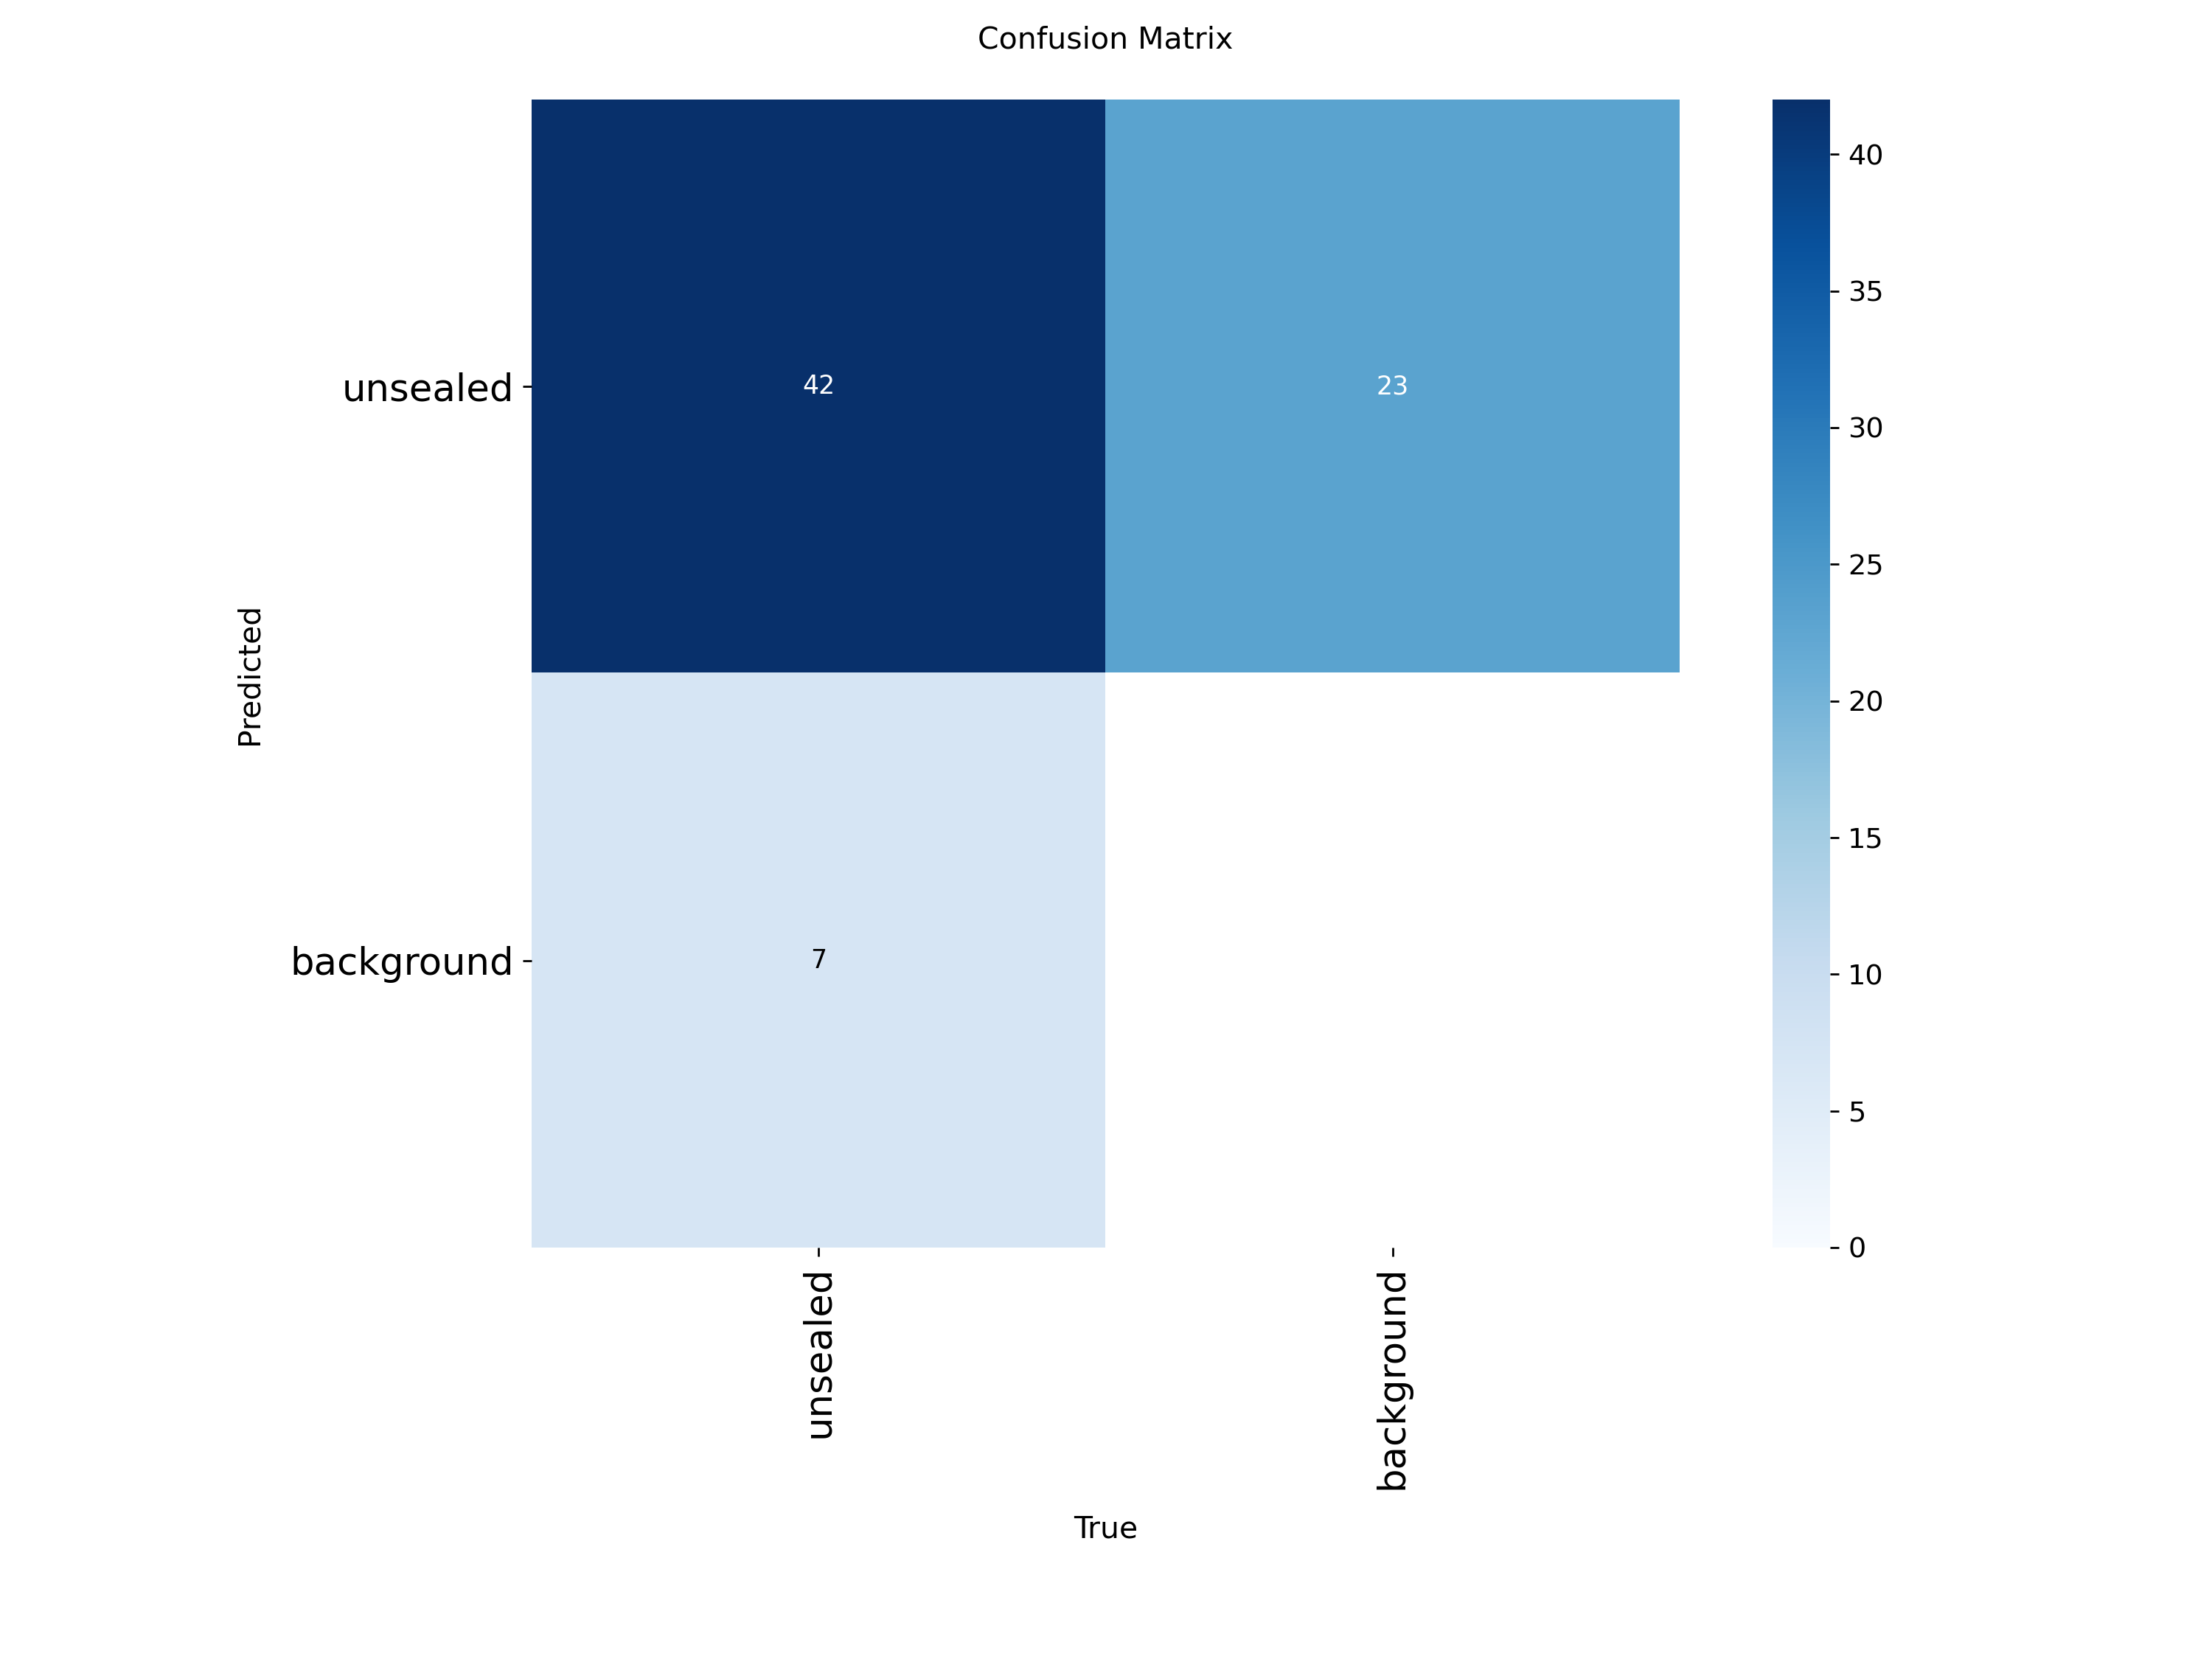

Ground-truth annotations


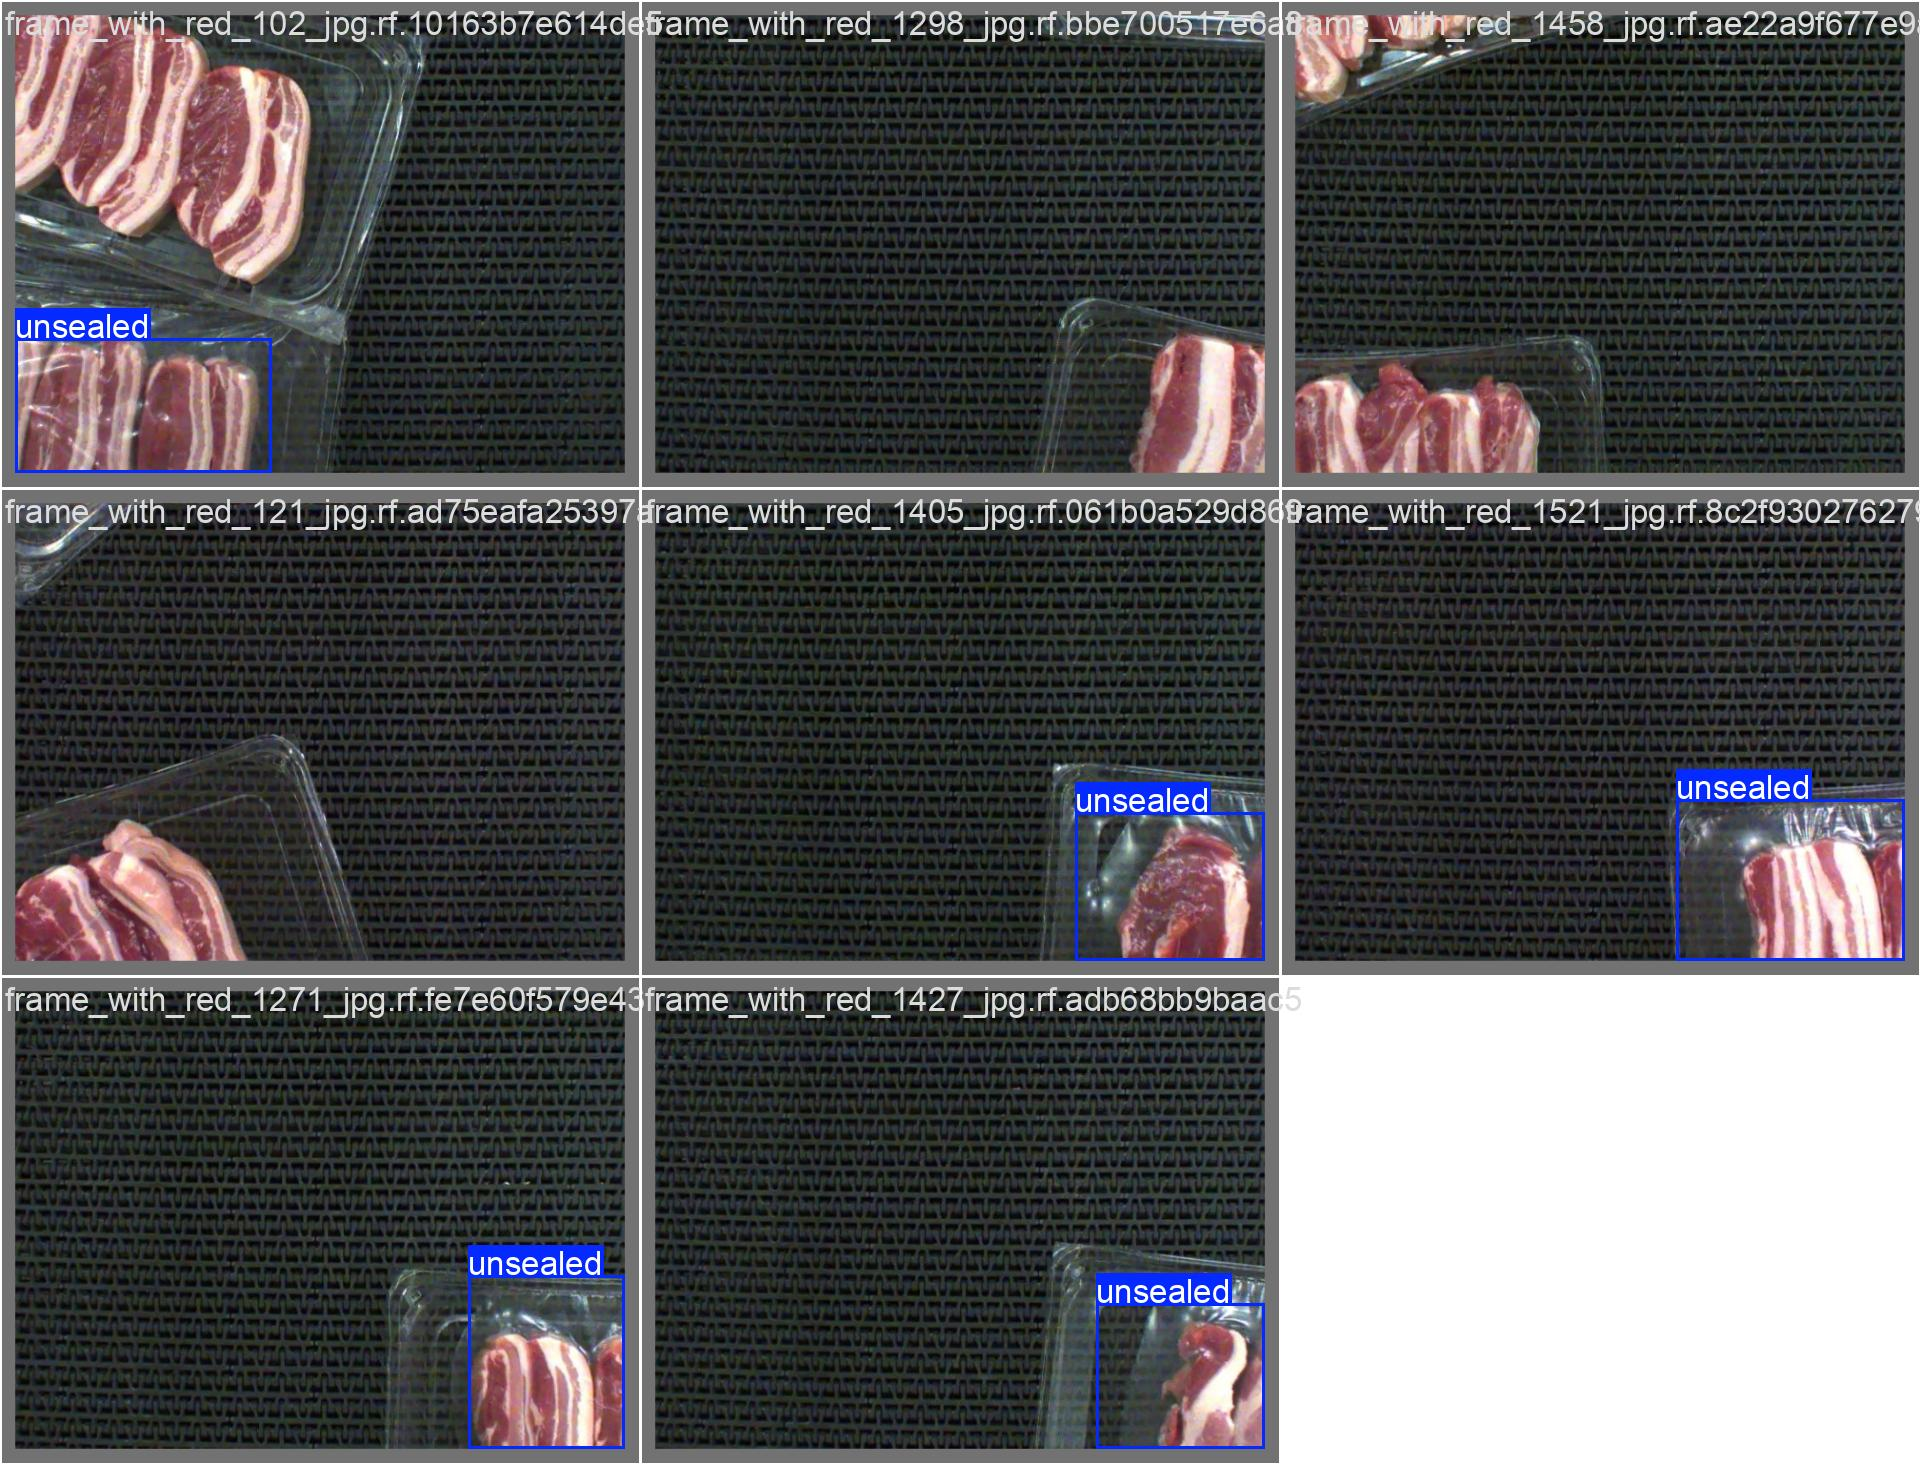

Model predictions


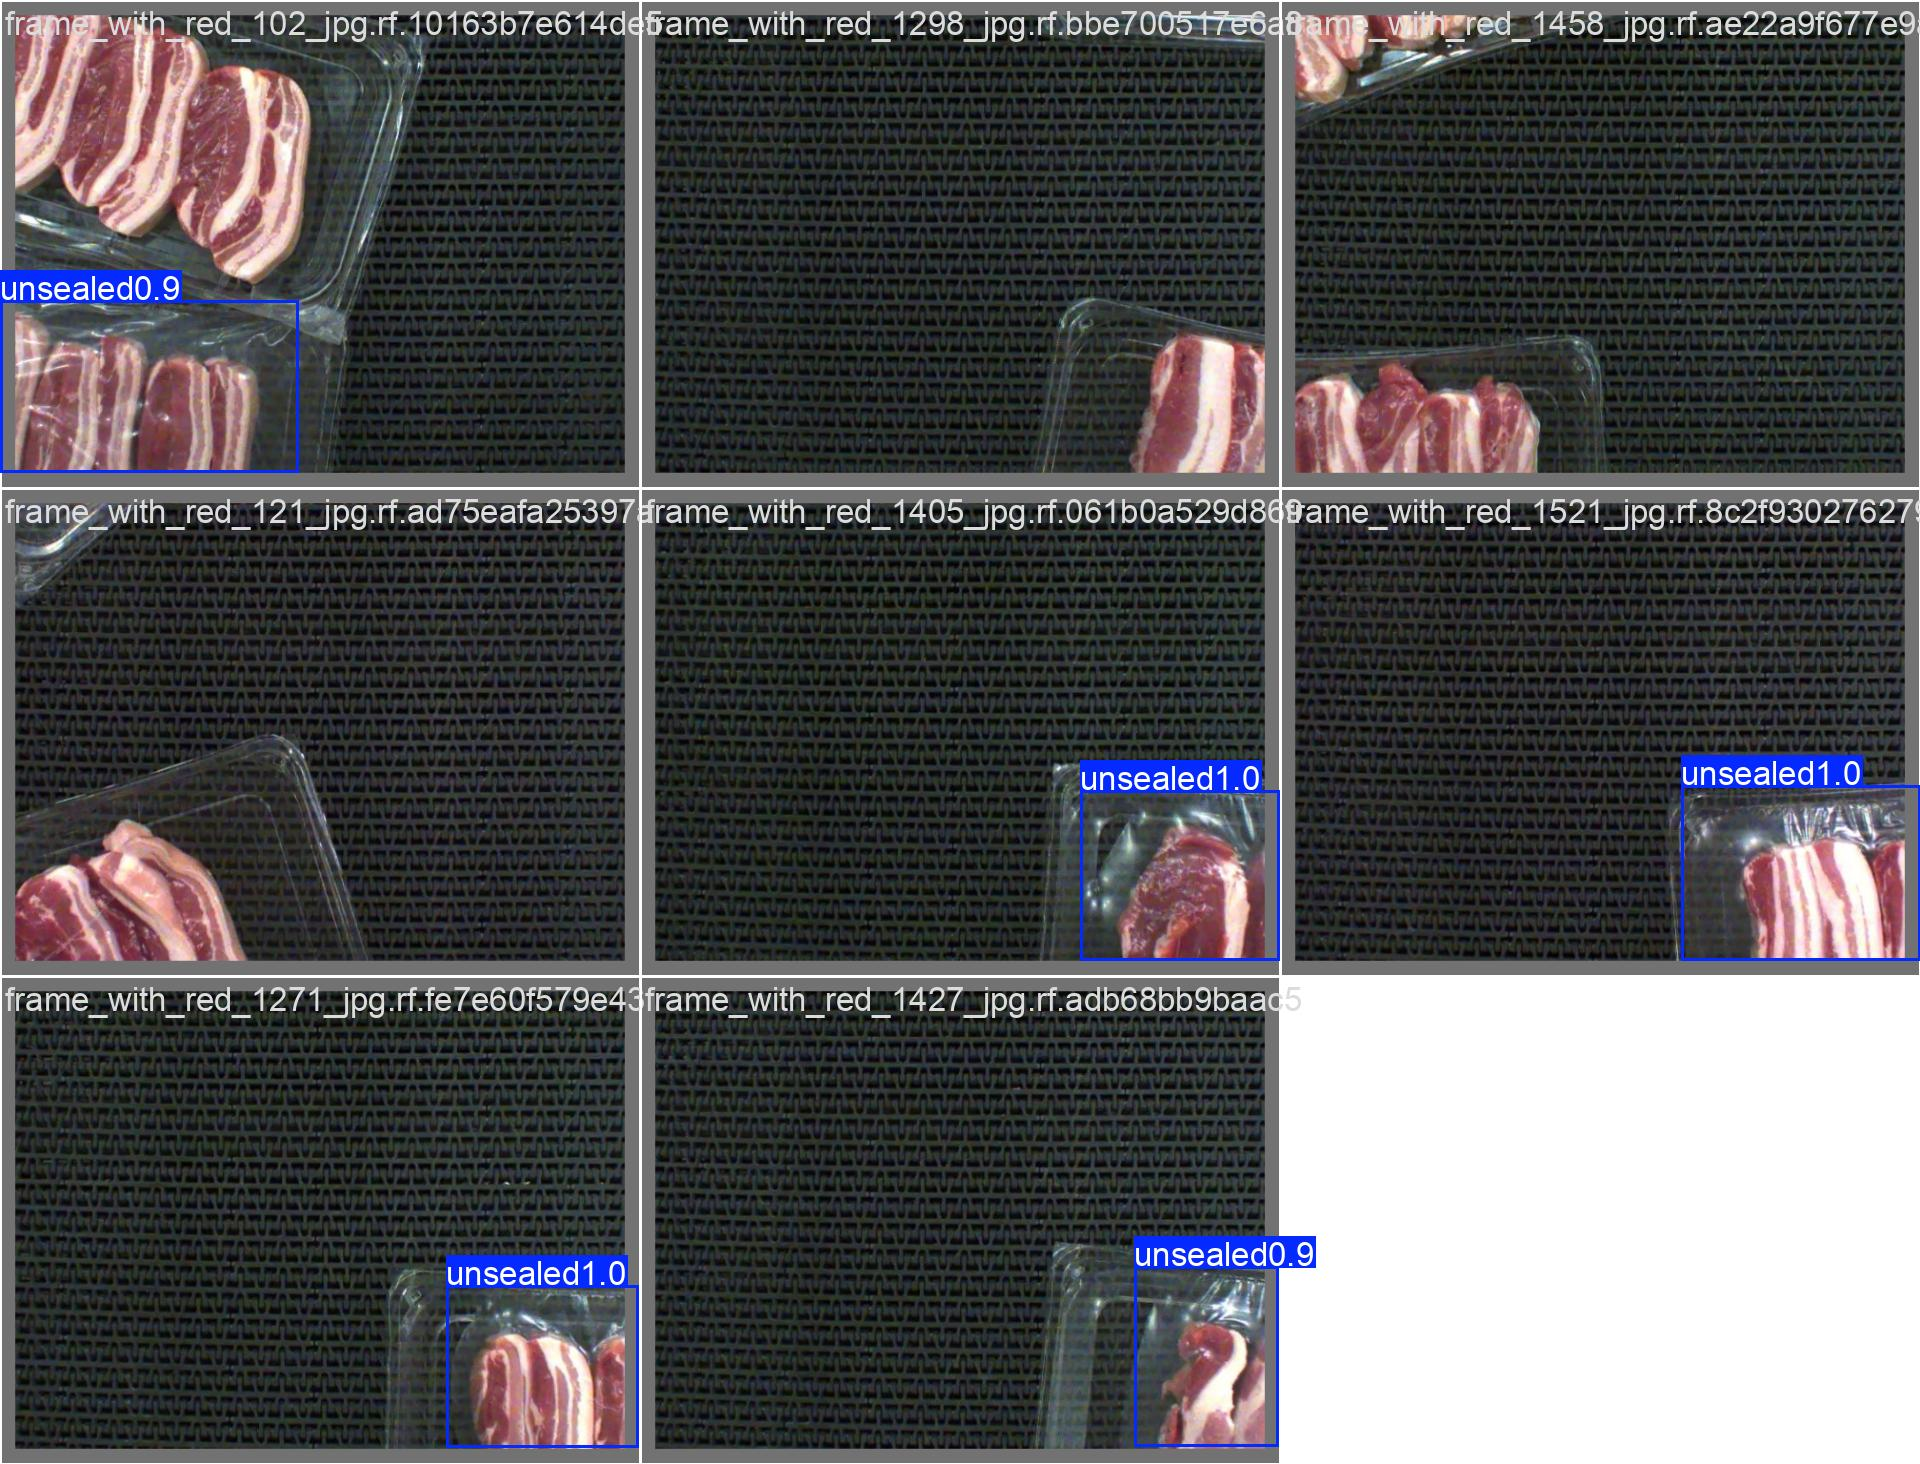

In [7]:
from pathlib import Path
from IPython.display import display, Image

plot_dir = Path(
    "/content/drive/MyDrive/MMA3001_Pork_Project/"
    "results/20261005_053211/final_test/yolov8n"
)

examples = [
    ("confusion_matrix.png", "Confusion matrix"),
    ("val_batch0_labels.jpg", "Ground-truth annotations"),
    ("val_batch0_pred.jpg", "Model predictions"),
]

for filename, title in examples:
    path = plot_dir / filename
    if path.exists():
        print(title)
        display(Image(filename=str(path), width=1000))
    else:
        print("File not found:", filename)

1. **Correct detections:** All five annotated unsealed regions in the displayed eight-image batch have overlapping predicted boxes. The other three images have no annotations or predicted boxes.

2. **Missed regions and extra detections:** No missed regions or extra boxes are visible in this displayed batch. Across the full test set, the plotted confusion matrix records 42 matched detections, 7 missed annotated regions and 23 unmatched predicted boxes, showing that errors occur in other images.

3. **Bounding-box alignment:** The predicted boxes generally overlap the annotated regions closely. However, the upper-left prediction is wider and taller than its annotation, while the bottom-middle prediction is narrower and shifted slightly to the right. The model identifies these regions, but their box boundaries are not exact.